In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_074_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_070_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_035_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_042_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_012_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_043_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_068_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_023_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label/20240529_EO4_RES2_fl_pid_078_label.tif
/kaggle/input/competitions/anrfaisehack-theme-1-phase2/

In [ ]:
!pip uninstall -y numpy scipy
!pip install numpy==2.2.6 scipy==1.16.3

!pip uninstall pytorch-lightning -y
!pip uninstall lightning -y
!pip uninstall lightning-fabric -y
!pip install lightning==2.2.1
!pip install terratorch --upgrade
!pip install earthengine-api geemap rasterio scikit-image --quiet

import os
os._exit(0)


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 54.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2

In [1]:
import os, numpy as np, pandas as pd
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import transform_bounds
from pathlib import Path

BASE_PATH       = "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data"
IMAGE_PATH      = os.path.join(BASE_PATH, "image")
LABEL_PATH      = os.path.join(BASE_PATH, "label")
SPLIT_PATH      = os.path.join(BASE_PATH, "split")
PRED_IMAGE_PATH = os.path.join(BASE_PATH, "prediction/image")

AUX_DIR         = "/kaggle/working/aux_data"
MERGED_DIR      = "/kaggle/working/merged_images"
MERGED_PRED_DIR = "/kaggle/working/merged_pred_images"

for d in [AUX_DIR, MERGED_DIR, MERGED_PRED_DIR]:
    os.makedirs(d, exist_ok=True)

def bounds_from_tif(tif_path):
    """Always returns WGS84 (lon/lat) bounds."""
    with rasterio.open(tif_path) as src:
        b, crs = src.bounds, src.crs
    if crs and not crs.is_geographic:
        left, bottom, right, top = transform_bounds(
            crs, "EPSG:4326", b.left, b.bottom, b.right, b.top)
    else:
        left, bottom, right, top = b.left, b.bottom, b.right, b.top
    return (left, bottom, right, top)

# Build PATCH_BOUNDS from TIF files
PATCH_BOUNDS = {}
for tif in sorted(Path(IMAGE_PATH).glob("*_image.tif")):
    pid = int(tif.stem.split("_pid_")[1].split("_")[0])
    PATCH_BOUNDS[pid] = bounds_from_tif(str(tif))

pred_patch_bounds = {}
for tif in sorted(Path(PRED_IMAGE_PATH).glob("*_image.tif")):
    pid = int(tif.stem.split("_pid_")[1].split("_")[0])
    pred_patch_bounds[pid] = bounds_from_tif(str(tif))

ALL_BOUNDS = {**PATCH_BOUNDS, **pred_patch_bounds}

print(f"✅ Paths ready")
print(f"   Train patches  : {len(PATCH_BOUNDS)}")
print(f"   Pred patches   : {sorted(pred_patch_bounds.keys())}")
print(f"   AUX_DIR        : {AUX_DIR}")
print(f"   MERGED_DIR     : {MERGED_DIR}")


✅ Paths ready
   Train patches  : 79
   Pred patches   : [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98]
   AUX_DIR        : /kaggle/working/aux_data
   MERGED_DIR     : /kaggle/working/merged_images


In [2]:
!pip install earthengine-api geemap rasterio numpy pandas --quiet


In [3]:
import pandas as pd, re, os, json
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from pathlib import Path

# ── Exact bounds for every training patch (from geo_report.csv) ───────────
# West Bengal, India — May 29 2024 flood event
# All patches are 512×512 pixels at 18m resolution (≈0.08593° per side)

PATCH_BOUNDS = {
    1: (88.14287631, 21.59578431, 88.22880613, 21.68171413),
    2: (88.22880613, 21.59578431, 88.31473594, 21.68171413),
    3: (88.31473594, 21.59578431, 88.40066576, 21.68171413),
    4: (88.40066576, 21.59578431, 88.48659558, 21.68171413),
    5: (88.14287631, 21.68171413, 88.22880613, 21.76764394),
    6: (88.22880613, 21.68171413, 88.31473594, 21.76764394),
    7: (88.31473594, 21.68171413, 88.40066576, 21.76764394),
    8: (88.40066576, 21.68171413, 88.48659558, 21.76764394),
    9: (88.14287631, 21.76764394, 88.22880613, 21.85357376),
    10: (88.22880613, 21.76764394, 88.31473594, 21.85357376),
    11: (88.31473594, 21.76764394, 88.40066576, 21.85357376),
    12: (88.40066576, 21.76764394, 88.48659558, 21.85357376),
    13: (88.48659558, 21.76764394, 88.57252540, 21.85357376),
    14: (88.14287631, 21.85357376, 88.22880613, 21.93950358),
    15: (88.22880613, 21.85357376, 88.31473594, 21.93950358),
    16: (88.31473594, 21.85357376, 88.40066576, 21.93950358),
    17: (88.40066576, 21.85357376, 88.48659558, 21.93950358),
    18: (88.48659558, 21.85357376, 88.57252540, 21.93950358),
    19: (88.14287631, 21.93950358, 88.22880613, 22.02543339),
    20: (88.22880613, 21.93950358, 88.31473594, 22.02543339),
    21: (88.31473594, 21.93950358, 88.40066576, 22.02543339),
    22: (88.40066576, 21.93950358, 88.48659558, 22.02543339),
    23: (88.48659558, 21.93950358, 88.57252540, 22.02543339),
    24: (88.57252540, 21.93950358, 88.65845521, 22.02543339),
    25: (88.65845521, 21.93950358, 88.74438503, 22.02543339),
    26: (88.14287631, 22.02543339, 88.22880613, 22.11136321),
    27: (88.22880613, 22.02543339, 88.31473594, 22.11136321),
    28: (88.31473594, 22.02543339, 88.40066576, 22.11136321),
    29: (88.40066576, 22.02543339, 88.48659558, 22.11136321),
    30: (88.48659558, 22.02543339, 88.57252540, 22.11136321),
    31: (88.57252540, 22.02543339, 88.65845521, 22.11136321),
    32: (88.65845521, 22.02543339, 88.74438503, 22.11136321),
    33: (88.74438503, 22.02543339, 88.83031485, 22.11136321),
    34: (88.83031485, 22.02543339, 88.91624467, 22.11136321),
    35: (88.91624467, 22.02543339, 89.00217448, 22.11136321),
    36: (88.14287631, 22.11136321, 88.22880613, 22.19729303),
    37: (88.22880613, 22.11136321, 88.31473594, 22.19729303),
    38: (88.31473594, 22.11136321, 88.40066576, 22.19729303),
    39: (88.40066576, 22.11136321, 88.48659558, 22.19729303),
    40: (88.48659558, 22.11136321, 88.57252540, 22.19729303),
    41: (88.57252540, 22.11136321, 88.65845521, 22.19729303),
    42: (88.65845521, 22.11136321, 88.74438503, 22.19729303),
    43: (88.74438503, 22.11136321, 88.83031485, 22.19729303),
    44: (88.83031485, 22.11136321, 88.91624467, 22.19729303),
    45: (88.91624467, 22.11136321, 89.00217448, 22.19729303),
    46: (88.14287631, 22.19729303, 88.22880613, 22.28322285),
    47: (88.22880613, 22.19729303, 88.31473594, 22.28322285),
    48: (88.31473594, 22.19729303, 88.40066576, 22.28322285),
    49: (88.40066576, 22.19729303, 88.48659558, 22.28322285),
    50: (88.48659558, 22.19729303, 88.57252540, 22.28322285),
    51: (88.57252540, 22.19729303, 88.65845521, 22.28322285),
    52: (88.65845521, 22.19729303, 88.74438503, 22.28322285),
    53: (88.74438503, 22.19729303, 88.83031485, 22.28322285),
    54: (88.83031485, 22.19729303, 88.91624467, 22.28322285),
    55: (88.91624467, 22.19729303, 89.00217448, 22.28322285),
    56: (88.14287631, 22.28322285, 88.22880613, 22.36915266),
    57: (88.22880613, 22.28322285, 88.31473594, 22.36915266),
    58: (88.48659558, 22.28322285, 88.57252540, 22.36915266),
    59: (88.57252540, 22.28322285, 88.65845521, 22.36915266),
    60: (88.65845521, 22.28322285, 88.74438503, 22.36915266),
    61: (88.74438503, 22.28322285, 88.83031485, 22.36915266),
    62: (88.83031485, 22.28322285, 88.91624467, 22.36915266),
    63: (88.91624467, 22.28322285, 89.00217448, 22.36915266),
    64: (88.14287631, 22.36915266, 88.22880613, 22.45508248),
    65: (88.40066576, 22.36915266, 88.48659558, 22.45508248),
    66: (88.48659558, 22.36915266, 88.57252540, 22.45508248),
    67: (88.57252540, 22.36915266, 88.65845521, 22.45508248),
    68: (88.65845521, 22.36915266, 88.74438503, 22.45508248),
    69: (88.74438503, 22.36915266, 88.83031485, 22.45508248),
    70: (88.83031485, 22.36915266, 88.91624467, 22.45508248),
    71: (88.91624467, 22.36915266, 89.00217448, 22.45508248),
    72: (88.31473594, 22.45508248, 88.40066576, 22.54101230),
    73: (88.40066576, 22.45508248, 88.48659558, 22.54101230),
    74: (88.48659558, 22.45508248, 88.57252540, 22.54101230),
    75: (88.57252540, 22.45508248, 88.65845521, 22.54101230),
    76: (88.65845521, 22.45508248, 88.74438503, 22.54101230),
    77: (88.74438503, 22.45508248, 88.83031485, 22.54101230),
    78: (88.83031485, 22.45508248, 88.91624467, 22.54101230),
    79: (88.91624467, 22.45508248, 89.00217448, 22.54101230),
}

# Prediction patches: pid 80-98 (assumed grid continuation)
# Will be derived from the pattern above in the download step.

# Overall region bounding box (with 0.05° buffer)
REGION_BOUNDS = (88.09, 21.54, 89.05, 22.60)   # (W, S, E, N)

AUX_DIR = "/kaggle/working/aux_data"
os.makedirs(AUX_DIR, exist_ok=True)

print(f" Bounds loaded for {len(PATCH_BOUNDS)} training patches")
print(f"   Study area: {REGION_BOUNDS}")


 Bounds loaded for 79 training patches
   Study area: (88.09, 21.54, 89.05, 22.6)


In [4]:
import ee

ee.Authenticate(auth_mode='notebook')
ee.Initialize(project="sacred-particle-450913-p0")

print(" GEE initialized")

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=_wTM6Y2t87PLLlW8A0xm0_-4DjvlCKQtCNs4My9pF7U&tc=4dWhKLI_xMGOdnfuzsaOvbjAKqESxTppEE206v6v_3w&cc=O2cW90Zaa522uQMoq7MlgfENNIX52q7GhSGUb-pNGys

The authorization workflow will generate a code, which you should paste in the box below.


Enter verification code:  4/1Aci98E9ndP_vOqiN9pe0mCibSRiJmi8tKvDyiUoPp1HabP13kj8HnhVxh6w



Successfully saved authorization token.
 GEE initialized


In [5]:
import ee, os, time
import numpy as np
import rasterio
from rasterio.io import MemoryFile
from rasterio.transform import from_bounds
from rasterio.warp import transform_bounds
from skimage.transform import resize

# ─────────────────────────────────────────────────────────────────────────
# REWRITE: switch from getDownloadURL → ee.data.computePixels()
#
# Root cause of all 400s: getDownloadURL is unreliable for multi-band
# stacks with mixed data types (float/int/categorical) in recent GEE
# Python API versions.
#
# ee.data.computePixels() is the modern replacement:
#   - Returns raw bytes directly (no zip, no temp files)
#   - Explicit pixel grid control (exact 512×512 output, no resize needed)
#   - No per-request size limits like getDownloadURL
#   - Works on mixed-type stacks
# ─────────────────────────────────────────────────────────────────────────

ee.Initialize()
print("✅ GEE session initialised")

SCALE = 18

# ── Image stack ───────────────────────────────────────────────────────────
gsw = (ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
       .select("occurrence").unmask(0).rename("gsw_occurrence"))
dem        = ee.Image("USGS/SRTMGL1_003").select("elevation").rename("elevation")
slope      = ee.Terrain.slope(dem).rename("slope")
worldcover = (ee.ImageCollection("ESA/WorldCover/v200")
              .first().select("Map").rename("landcover"))
pre_flood_sar = (ee.ImageCollection("COPERNICUS/S1_GRD")
                 .filterDate("2024-05-15", "2024-05-28")
                 .filter(ee.Filter.eq("instrumentMode", "IW"))
                 .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
                 .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
                 .select(["VV", "VH"])
                 .mean()
                 .rename(["pre_vv", "pre_vh"]))

# Cast ALL bands to float32 — mixed types (int/float/categorical) cause
# the 400 errors with getDownloadURL; computePixels needs uniform type
aux_stack = (gsw.float()
               .addBands(dem.float())
               .addBands(slope.float())
               .addBands(worldcover.float())
               .addBands(pre_flood_sar.float()))

BAND_NAMES = ["gsw_occurrence", "elevation", "slope",
              "landcover", "pre_vv", "pre_vh"]
print("Stack bands:", aux_stack.bandNames().getInfo())


# ── bounds_from_tif: always WGS84 ────────────────────────────────────────
def bounds_from_tif(tif_path):
    with rasterio.open(tif_path) as src:
        b, crs = src.bounds, src.crs
    if crs and not crs.is_geographic:
        left, bottom, right, top = transform_bounds(
            crs, "EPSG:4326", b.left, b.bottom, b.right, b.top)
    else:
        left, bottom, right, top = b.left, b.bottom, b.right, b.top
    return (left, bottom, right, top)


# ── Rebuild PATCH_BOUNDS ──────────────────────────────────────────────────
IMAGE_PATH = "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/image"
PATCH_BOUNDS = {}
for tif in sorted(Path(IMAGE_PATH).glob("*_image.tif")):
    pid = int(tif.stem.split("_pid_")[1].split("_")[0])
    PATCH_BOUNDS[pid] = bounds_from_tif(str(tif))
print(f"Train patches: {len(PATCH_BOUNDS)}")

PRED_IMAGE_PATH = "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/prediction/image"
pred_patch_bounds = {}
for tif in sorted(Path(PRED_IMAGE_PATH).glob("*_image.tif")):
    pid = int(tif.stem.split("_pid_")[1].split("_")[0])
    pred_patch_bounds[pid] = bounds_from_tif(str(tif))
print(f"Prediction patches: {sorted(pred_patch_bounds.keys())}")

ALL_BOUNDS = {**PATCH_BOUNDS, **pred_patch_bounds}
print(f"Total: {len(ALL_BOUNDS)} patches")

sb = ALL_BOUNDS[next(iter(ALL_BOUNDS))]
assert 85 < sb[0] < 92 and 20 < sb[1] < 26, f"Unexpected bounds: {sb}"
print(f"✅ Bounds OK — sample: {sb}")


# ── Per-patch download via computePixels ─────────────────────────────────
def download_patch_aux(pid, bounds, retries=3):
    """
    Fetch 6-band aux raster using ee.data.computePixels().
    Returns raw GeoTIFF bytes directly — no zip, no temp files.
    Output is exactly 512×512 (pixel grid specified explicitly).
    """
    out_path = os.path.join(AUX_DIR, f"pid_{pid:03d}_raw.tif")

    # Skip if already successfully downloaded (non-zero content)
    if os.path.exists(out_path):
        with rasterio.open(out_path) as src:
            if src.read(1).max() != 0:   # has real data
                return out_path, True
        os.remove(out_path)   # remove stale zeros placeholder, re-download

    left, bottom, right, top = bounds
    px = (right - left) / 512   # pixel width  in degrees
    py = (top - bottom) / 512   # pixel height in degrees

    request = {
        "expression": aux_stack,
        "fileFormat": "GEO_TIFF",
        "bandIds": BAND_NAMES,
        "grid": {
            "dimensions": {"width": 512, "height": 512},
            "affineTransform": {
                "scaleX":     px,   "shearX": 0, "translateX": left,
                "shearY": 0, "scaleY": -py,      "translateY": top,
            },
            "crsCode": "EPSG:4326",
        },
    }

    for attempt in range(retries):
        try:
            raw = ee.data.computePixels(request)   # returns bytes

            with MemoryFile(raw) as mem:
                with mem.open() as ds:
                    arrays  = [ds.read(i+1).astype(np.float32)
                               for i in range(ds.count)]
                    profile = ds.profile.copy()

            profile.update(
                driver="GTiff", dtype="float32",
                count=len(arrays), width=512, height=512,
                transform=from_bounds(left, bottom, right, top, 512, 512),
                crs="EPSG:4326"
            )
            with rasterio.open(out_path, "w", **profile) as dst:
                for i, arr in enumerate(arrays):
                    dst.write(arr, i + 1)

            return out_path, True   # success

        except Exception as ex:
            wait = 20 * (attempt + 1)   # 20s, 40s, 60s
            if attempt < retries - 1:
                print(f"   pid {pid} attempt {attempt+1} failed: {ex} — retry in {wait}s")
                try: ee.Initialize()
                except Exception: pass
                time.sleep(wait)
            else:
                print(f"   pid {pid} failed after {retries} attempts: {ex} — saving zeros")
                zero_profile = {
                    "driver": "GTiff", "dtype": "float32", "count": 6,
                    "width": 512, "height": 512, "crs": "EPSG:4326",
                    "transform": from_bounds(left, bottom, right, top, 512, 512)
                }
                with rasterio.open(out_path, "w", **zero_profile) as dst:
                    for i in range(6):
                        dst.write(np.zeros((512, 512), np.float32), i + 1)
                return out_path, False


# ── Download loop ─────────────────────────────────────────────────────────
failed, done = [], 0
for pid, bounds in sorted(ALL_BOUNDS.items()):
    path, ok = download_patch_aux(pid, bounds)
    done += 1
    status = "✓" if ok else "✗ (zeros)"
    if not ok:
        failed.append(pid)
    print(f"  {status} pid {pid:3d}  ({done}/{len(ALL_BOUNDS)})")
    time.sleep(1.0)

print(f"\n✅ Done: {done - len(failed)}/{len(ALL_BOUNDS)} patches → {AUX_DIR}")
if failed:
    print(f"  ⚠ Zero placeholders (aux only, main SAR/optical unaffected): {failed}")

✅ GEE session initialised
Stack bands: ['gsw_occurrence', 'elevation', 'slope', 'landcover', 'pre_vv', 'pre_vh']
Train patches: 79
Prediction patches: [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98]
Total: 98 patches
✅ Bounds OK — sample: (88.14287630943818, 21.59578430810345, 88.22880612675132, 21.68171412541659)
  ✓ pid   1  (1/98)
  ✓ pid   2  (2/98)
  ✓ pid   3  (3/98)
  ✓ pid   4  (4/98)
  ✓ pid   5  (5/98)
  ✓ pid   6  (6/98)
  ✓ pid   7  (7/98)
  ✓ pid   8  (8/98)
  ✓ pid   9  (9/98)
  ✓ pid  10  (10/98)
  ✓ pid  11  (11/98)
  ✓ pid  12  (12/98)
  ✓ pid  13  (13/98)
  ✓ pid  14  (14/98)
  ✓ pid  15  (15/98)
  ✓ pid  16  (16/98)
  ✓ pid  17  (17/98)
  ✓ pid  18  (18/98)
  ✓ pid  19  (19/98)
  ✓ pid  20  (20/98)
  ✓ pid  21  (21/98)
  ✓ pid  22  (22/98)
  ✓ pid  23  (23/98)
  ✓ pid  24  (24/98)
  ✓ pid  25  (25/98)
  ✓ pid  26  (26/98)
  ✓ pid  27  (27/98)
  ✓ pid  28  (28/98)
  ✓ pid  29  (29/98)
  ✓ pid  30  (30/98)
  ✓ pid  31  (31/98)
  ✓ pid  32  

In [6]:
def load_aux_patch(patch_id):
    """
    Load pre-downloaded aux TIF. Returns (6, 512, 512) float32, normalised 0-1:
      0: gsw_occurrence  → / 100
      1: elevation       → min-max normalised
      2: slope           → / 45°
      3: landcover       → / 100
      4: pre_vv          → dB clip [-25, 0] → 0-1
      5: pre_vh          → dB clip [-30, -5] → 0-1
    Falls back to zeros if file missing/corrupt.
    """
    path = os.path.join(AUX_DIR, f"pid_{patch_id:03d}_raw.tif")
    try:
        with rasterio.open(path) as src:
            data = src.read().astype(np.float32)
    except Exception:
        return np.zeros((6, 512, 512), dtype=np.float32)

    gsw_n  = np.clip(data[0] / 100.0, 0, 1)
    elev   = data[1]
    elev_n = np.clip((elev - elev.min()) / (elev.max() - elev.min() + 1e-6), 0, 1)
    slp_n  = np.clip(data[2] / 45.0, 0, 1)
    lc_n   = np.clip(data[3] / 100.0, 0, 1)
    vv_n   = np.clip((data[4] - (-25)) / 25.0, 0, 1)
    vh_n   = np.clip((data[5] - (-30)) / 25.0, 0, 1)
    return np.stack([gsw_n, elev_n, slp_n, lc_n, vv_n, vh_n], axis=0)


# Sanity check
test = load_aux_patch(1)
print(f"Shape : {test.shape}")
print(f"Range : min={test.min():.3f}  max={test.max():.3f}")
print(f"GSW   : mean={test[0].mean():.3f}  (0=land, 1=permanent water)")
print(f"Elev  : mean={test[1].mean():.3f}")
print(f"Pre-VV: mean={test[4].mean():.3f}")
print("✅ load_aux_patch ready")


Shape : (6, 512, 512)
Range : min=0.000  max=1.000
GSW   : mean=0.644  (0=land, 1=permanent water)
Elev  : mean=0.330
Pre-VV: mean=0.365
✅ load_aux_patch ready


In [7]:
# ── Merge 3 best aux channels into 9-channel TIFs ─────────────────────────
# Only use the 3 most discriminative aux channels to stay within Prithvi's
# safe range (10ch worked; we add 3 → 9 original + 4 engineered = 13 total):
#   ch 6: gsw_occurrence  — permanent water prior (key for flood vs water-body)
#   ch 7: elevation       — flood only occurs in low areas
#   ch 8: pre_vv          — pre-flood SAR baseline (temporal change signal)
AUX_INDICES = [0, 1, 4]   # gsw, elevation, pre_vv

def merge_patch(img_path, pid, out_dir):
    aux = load_aux_patch(pid)          # (6, 512, 512)
    aux_3 = aux[AUX_INDICES]           # (3, 512, 512)

    with rasterio.open(img_path) as src:
        img     = src.read().astype(np.float32)   # (6, 512, 512)
        profile = src.profile.copy()

    merged = np.concatenate([img, aux_3], axis=0)   # (9, 512, 512)
    profile.update(count=9, dtype="float32")

    out_path = os.path.join(out_dir, os.path.basename(img_path))
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(merged)
    return out_path

# Train / val / test images (pid 1-79)
print("Merging train/val/test images...")
for tif in sorted(Path(IMAGE_PATH).glob("*_image.tif")):
    pid = int(tif.stem.split("_pid_")[1].split("_")[0])
    merge_patch(str(tif), pid, MERGED_DIR)
    print(f"  ✓ pid {pid:3d}")

# Prediction images (pid 80-98)
print("\nMerging prediction images...")
for tif in sorted(Path(PRED_IMAGE_PATH).glob("*_image.tif")):
    pid = int(tif.stem.split("_pid_")[1].split("_")[0])
    merge_patch(str(tif), pid, MERGED_PRED_DIR)
    print(f"  ✓ pid {pid:3d} (pred)")

print(f"\n✅ Merged TIFs ready")
print(f"   Channels 0-5 : original SAR + optical")
print(f"   Channel 6    : GSW occurrence (permanent water prior) ★")
print(f"   Channel 7    : Elevation (normalised)")
print(f"   Channel 8    : Pre-flood SAR VV (temporal baseline) ★")


Merging train/val/test images...
  ✓ pid   1
  ✓ pid   2
  ✓ pid   3
  ✓ pid   4
  ✓ pid   5
  ✓ pid   6
  ✓ pid   7
  ✓ pid   8
  ✓ pid   9
  ✓ pid  10
  ✓ pid  11
  ✓ pid  12
  ✓ pid  13
  ✓ pid  14
  ✓ pid  15
  ✓ pid  16
  ✓ pid  17
  ✓ pid  18
  ✓ pid  19
  ✓ pid  20
  ✓ pid  21
  ✓ pid  22
  ✓ pid  23
  ✓ pid  24
  ✓ pid  25
  ✓ pid  26
  ✓ pid  27
  ✓ pid  28
  ✓ pid  29
  ✓ pid  30
  ✓ pid  31
  ✓ pid  32
  ✓ pid  33
  ✓ pid  34
  ✓ pid  35
  ✓ pid  36
  ✓ pid  37
  ✓ pid  38
  ✓ pid  39
  ✓ pid  40
  ✓ pid  41
  ✓ pid  42
  ✓ pid  43
  ✓ pid  44
  ✓ pid  45
  ✓ pid  46
  ✓ pid  47
  ✓ pid  48
  ✓ pid  49
  ✓ pid  50
  ✓ pid  51
  ✓ pid  52
  ✓ pid  53
  ✓ pid  54
  ✓ pid  55
  ✓ pid  56
  ✓ pid  57
  ✓ pid  58
  ✓ pid  59
  ✓ pid  60
  ✓ pid  61
  ✓ pid  62
  ✓ pid  63
  ✓ pid  64
  ✓ pid  65
  ✓ pid  66
  ✓ pid  67
  ✓ pid  68
  ✓ pid  69
  ✓ pid  70
  ✓ pid  71
  ✓ pid  72
  ✓ pid  73
  ✓ pid  74
  ✓ pid  75
  ✓ pid  76
  ✓ pid  77
  ✓ pid  78
  ✓ pid  79

Merging prediction

In [8]:
sample = sorted(Path(MERGED_DIR).glob("*_image.tif"))[0]
with rasterio.open(sample) as src:
    d = src.read()
print(f"Shape  : {d.shape}")   # expect (9, 512, 512)
print(f"Ch 0-5 (original): min={d[:6].min():.3f}  max={d[:6].max():.3f}")
print(f"Ch 6 GSW         : mean={d[6].mean():.3f}  (0=land, 1=water)")
print(f"Ch 7 Elevation   : mean={d[7].mean():.3f}")
print(f"Ch 8 Pre-VV      : mean={d[8].mean():.3f}")
assert d.shape[0] == 9, "Expected 9 channels"
print("✅ Merged TIF verified")


Shape  : (9, 512, 512)
Ch 0-5 (original): min=34.266  max=9072.176
Ch 6 GSW         : mean=0.644  (0=land, 1=water)
Ch 7 Elevation   : mean=0.330
Ch 8 Pre-VV      : mean=0.365
✅ Merged TIF verified


In [9]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F

import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

from scipy.ndimage import median_filter, sobel, uniform_filter, distance_transform_edt
from skimage.morphology import remove_small_objects, binary_closing
from scipy.ndimage import binary_fill_holes

import lightning as pl
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

from terratorch.datamodules import GenericNonGeoSegmentationDataModule
from terratorch.tasks import SemanticSegmentationTask

import warnings
warnings.filterwarnings("ignore")

print("✅ All imports ready")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


✅ All imports ready


In [10]:
def preprocess_image(img):
    """Percentile normalisation + SAR denoising. Input/output: (C, H, W) float32."""
    img = img.astype(np.float32)
    for i in range(img.shape[0]):
        p2, p98 = np.percentile(img[i], (2, 98))
        img[i]  = np.clip(img[i], p2, p98)
        img[i]  = (img[i] - p2) / (p98 - p2 + 1e-6)
    # SAR denoising on first two channels
    img[0] = median_filter(img[0], size=3)
    img[1] = median_filter(img[1], size=3)
    return img


In [11]:
def add_features(img):
    """
    Input : (9, H, W) — channels 0-5: original SAR+optical
                         channels 6-8: gsw_norm, elev_norm, pre_vv_norm (aux)
    Output: (13, H, W) — input 9 + 4 engineered SAR features

    Why 13 (not 15+): Prithvi EO v2 300 was pretrained on 6 spectral bands.
    backbone_bands up to ~13 adds only 7 extra random-init patch embedding
    positions — manageable signal-to-noise. Going to 15+ degraded mIoU.

    The 4 engineered features:
      texture     : SAR roughness — water is smooth, distinguishes water edges
      log_sar     : log-scale HH — linearises flood backscatter range
      hh_hv_ratio : double-bounce indicator ★ — flooded rice fields
      mndwi       : Modified NDWI ★ — best optical separator flood vs river
    """
    sar_hh = img[0]; sar_hv = img[1]
    green  = img[2]; nir = img[4]; swir = img[5]
    # channels 6-8 are pre-normalised aux, passed through unchanged

    # SAR texture (water = smooth = low texture)
    texture = np.abs(sobel(sar_hh)); texture /= (texture.max() + 1e-6)

    # Log SAR (compress dynamic range, emphasise low-backscatter water)
    sar_log = np.log1p(np.abs(sar_hh)); sar_log /= (sar_log.max() + 1e-6)

    # HH/HV ratio (double-bounce: flooded rice → high HH, lower HV)
    hh_hv_ratio = sar_hh / (sar_hv + 1e-6)
    hh_hv_ratio = np.clip(
        hh_hv_ratio / (np.percentile(np.abs(hh_hv_ratio), 98) + 1e-6), -2, 2)

    # MNDWI cloud-masked (separates flood from permanent water body)
    cloud_mask = (nir > np.percentile(nir, 93)).astype(np.float32)
    mndwi = np.clip((green - swir) / (green + swir + 1e-6), -1, 1)
    mndwi[cloud_mask == 1] = 0.0

    return np.concatenate([
        img,                # 0-8   original 6 + 3 aux
        texture[None],      # 9
        sar_log[None],      # 10
        hh_hv_ratio[None],  # 11
        mndwi[None],        # 12
    ], axis=0).astype(np.float32)   # → (13, H, W)

print("✅ add_features: (9, H, W) → (13, H, W)")
print("   0-5 : SAR HH/HV + Green/Red/NIR/SWIR")
print("   6   : GSW occurrence (permanent water prior) ★")
print("   7   : Elevation ★")
print("   8   : Pre-flood SAR VV ★")
print("   9   : SAR texture")
print("  10   : Log SAR")
print("  11   : HH/HV ratio (double-bounce) ★")
print("  12   : MNDWI cloud-masked ★")



✅ add_features: (9, H, W) → (13, H, W)
   0-5 : SAR HH/HV + Green/Red/NIR/SWIR
   6   : GSW occurrence (permanent water prior) ★
   7   : Elevation ★
   8   : Pre-flood SAR VV ★
   9   : SAR texture
  10   : Log SAR
  11   : HH/HV ratio (double-bounce) ★
  12   : MNDWI cloud-masked ★


In [12]:
class PreprocessTransform(A.ImageOnlyTransform):
    def apply(self, image, **params):
        image = image.transpose(2, 0, 1)   # HWC → CHW
        image = preprocess_image(image)    # normalise
        image = add_features(image)        # (9,H,W) → (13,H,W)
        return image.transpose(1, 2, 0)   # CHW → HWC

train_transform = [
    PreprocessTransform(p=1.0),
    A.D4(p=1.0),
    A.GaussianBlur(p=0.2),
    ToTensorV2()
]

val_transform = [
    PreprocessTransform(p=1.0),
    ToTensorV2()
]

print("✅ Transforms ready (input: 9ch TIF → output: 13ch tensor)")


✅ Transforms ready (input: 9ch TIF → output: 13ch tensor)


In [13]:
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=2,
    num_workers=0,
    num_classes=3,

    # ── Point to merged 9-channel TIFs ─────────────────────────────────
    train_data_root=MERGED_DIR,
    train_label_data_root=LABEL_PATH,
    val_data_root=MERGED_DIR,
    val_label_data_root=LABEL_PATH,
    test_data_root=MERGED_DIR,
    test_label_data_root=LABEL_PATH,

    train_split=os.path.join(SPLIT_PATH, "train.txt"),
    val_split=os.path.join(SPLIT_PATH, "val.txt"),
    test_split=os.path.join(SPLIT_PATH, "test.txt"),

    img_grep="*_image.tif",
    label_grep="*_label.tif",

    train_transform=train_transform,
    val_transform=val_transform,
    test_transform=val_transform,

    means=None,
    stds=None,
    no_data_replace=0,
    no_label_replace=-1,

    predict_data_root=MERGED_PRED_DIR,   # ← merged prediction images
)

datamodule.setup("fit")
print(f"✅ DataModule ready: {len(datamodule.train_dataset)} train samples")


✅ DataModule ready: 59 train samples


Image shape : torch.Size([13, 512, 512])
Mask classes: tensor([0, 1, 2])


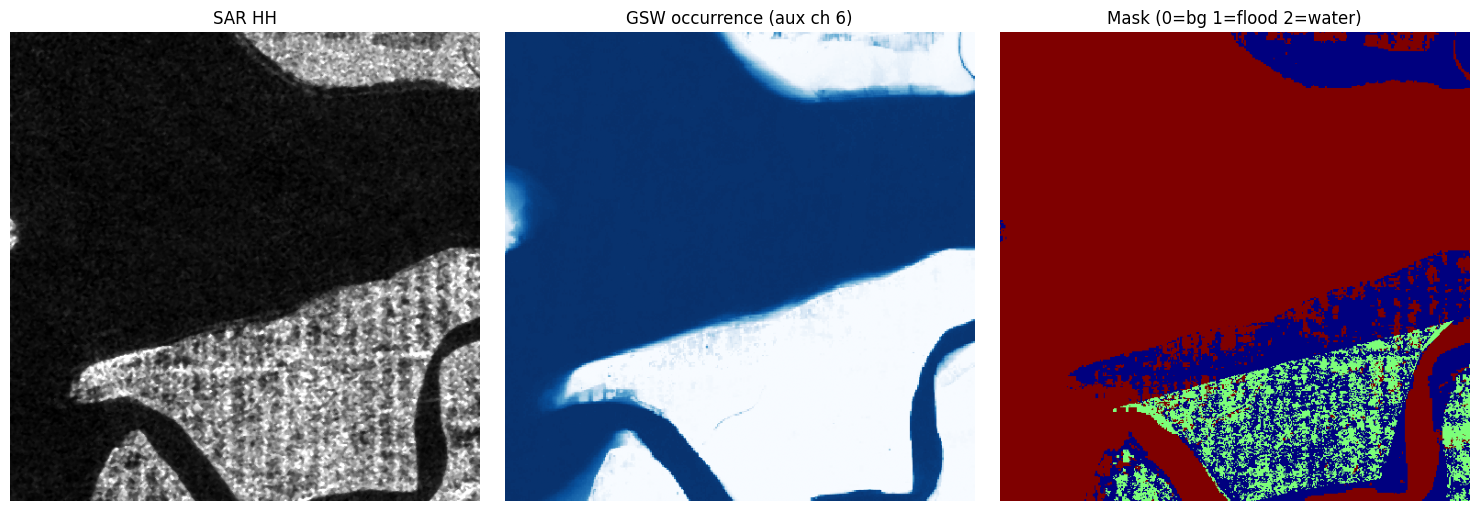

In [14]:
sample = datamodule.train_dataset[0]
img    = sample["image"]
mask   = sample["mask"]

print(f"Image shape : {img.shape}")   # (13, 512, 512)
print(f"Mask classes: {torch.unique(mask)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img[0].numpy(), cmap="gray"); axes[0].set_title("SAR HH"); axes[0].axis("off")
axes[1].imshow(img[6].numpy(), cmap="Blues"); axes[1].set_title("GSW occurrence (aux ch 6)"); axes[1].axis("off")
axes[2].imshow(mask.numpy(), cmap="jet"); axes[2].set_title("Mask (0=bg 1=flood 2=water)")
axes[2].axis("off")
plt.tight_layout(); plt.show()


In [15]:
OUT_DIR        = "output/flood_phase2_aux"
CHECKPOINT_DIR = os.path.join(OUT_DIR, "checkpoints")

EPOCHS       = 120
LR           = 5e-6
WEIGHT_DECAY = 0.05
NUM_CHANNELS = 13   # 6 orig + 3 aux + 4 engineered

pl.seed_everything(42)
print(f"✅ Config: {NUM_CHANNELS}ch input, LR={LR}, epochs={EPOCHS}")


Seed set to 42


✅ Config: 13ch input, LR=5e-06, epochs=120


In [16]:
class MultiTaskFocalDiceLoss(nn.Module):
    """
    Main 3-class focal+dice loss with two auxiliary binary tasks:
      Task 1 (water vs land)       : guides water detection    w=0.2
      Task 2 (flood vs water-body) : the Phase 2 hard problem  w=0.15
    Both derived from existing 3-class logits — no extra layers needed.
    """
    def __init__(self, class_weights=None, gamma=2.0, smooth=0.1,
                 w_water=0.2, w_discr=0.15):
        super().__init__()
        self.gamma = gamma; self.smooth = smooth
        self.w_water = w_water; self.w_discr = w_discr
        self.cw = torch.tensor(class_weights, dtype=torch.float32) if class_weights else None

    def _main_loss(self, logits, targets):
        valid = targets != -1
        lv = logits[valid.unsqueeze(1).expand_as(logits)].view(-1, 3)
        tv = targets[valid]
        ce    = F.cross_entropy(lv, tv,
                    weight=self.cw.to(logits.device) if self.cw is not None else None,
                    label_smoothing=self.smooth, reduction="none")
        focal = ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()
        probs = torch.softmax(logits, dim=1)
        t_oh  = F.one_hot(targets.clamp(0), 3).permute(0,3,1,2).float()
        m     = valid.float().unsqueeze(1)
        num   = (probs * t_oh * m).sum((0,2,3))
        den   = ((probs + t_oh) * m).sum((0,2,3))
        dice  = 1 - ((2*num+1e-6)/(den+1e-6)).mean()
        return 0.5*focal + 0.5*dice

    def _water_loss(self, logits, targets):
        valid = targets != -1
        water_t = ((targets==1)|(targets==2)).float()
        water_s = torch.max(logits[:,1], logits[:,2])
        return F.binary_cross_entropy_with_logits(water_s[valid], water_t[valid])

    def _discr_loss(self, logits, targets):
        water_px = (targets==1)|(targets==2)
        if water_px.sum() == 0:
            return torch.tensor(0.0, device=logits.device)
        flood_t = (targets==1).float()
        discr_s = logits[:,1] - logits[:,2]
        return F.binary_cross_entropy_with_logits(discr_s[water_px], flood_t[water_px])

    def forward(self, logits, targets):
        return (self._main_loss(logits, targets)
                + self.w_water * self._water_loss(logits, targets)
                + self.w_discr * self._discr_loss(logits, targets))

print("✅ MultiTaskFocalDiceLoss ready (w_water=0.2, w_discr=0.15)")


✅ MultiTaskFocalDiceLoss ready (w_water=0.2, w_discr=0.15)


In [23]:
import sys

class GradualUnfreeze(pl.Callback):
    """
    Fixed: filters out params already in the optimizer before adding
    the encoder as a new group. Required because freeze_backbone=False
    means all params are added to the optimizer at init time.
    """
    def __init__(self, unfreeze_epoch=20, encoder_lr=5e-7):
        self.unfreeze_epoch = unfreeze_epoch
        self.encoder_lr     = encoder_lr
        self._unfrozen      = False

    def on_train_epoch_start(self, trainer, pl_module):
        if trainer.current_epoch == self.unfreeze_epoch and not self._unfrozen:
            sys.stderr.write(
                f"\n🔓 Unfreezing encoder at epoch {self.unfreeze_epoch} "
                f"lr={self.encoder_lr}\n")

            # Unfreeze all encoder params
            for param in pl_module.model.encoder.parameters():
                param.requires_grad = True

            # Find params NOT already in any optimizer group
            existing = set()
            for group in trainer.optimizers[0].param_groups:
                for p in group["params"]:
                    existing.add(id(p))

            new_params = [
                p for p in pl_module.model.encoder.parameters()
                if id(p) not in existing
            ]

            if new_params:
                trainer.optimizers[0].add_param_group({
                    "params":       new_params,
                    "lr":           self.encoder_lr,
                    "weight_decay": 0.05,
                    "name":         "encoder_unfrozen"
                })
                sys.stderr.write(f"   Added {len(new_params)} new params at lr={self.encoder_lr}\n")
            else:
                # All encoder params already in optimizer — just set their LR
                for group in trainer.optimizers[0].param_groups:
                    enc_params = set(id(p) for p in pl_module.model.encoder.parameters())
                    if any(id(p) in enc_params for p in group["params"]):
                        group["lr"] = self.encoder_lr
                sys.stderr.write(f"   All encoder params already in optimizer — LR set to {self.encoder_lr}\n")

            self._unfrozen = True

print("✅ GradualUnfreeze fixed (handles params already in optimizer)")

✅ GradualUnfreeze fixed (handles params already in optimizer)


In [24]:
class_weights = [0.2, 18.0, 0.6]   # flood weight elevated

model = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args={
        "backbone": "prithvi_eo_v2_300_tl",
        "backbone_pretrained": True,
        "backbone_num_frames": 1,
        "backbone_bands": list(range(1, 14)),   # 13 channels
        "backbone_coords_encoding": [],
        "necks": [
            {"name": "SelectIndices", "indices": [3, 7, 11, 15]},
            {"name": "ReshapeTokensToImage"},
            {"name": "LearnedInterpolateToPyramidal"},
        ],
        "decoder": "UNetDecoder",
        "decoder_channels": [512, 256, 128, 64],
        "head_dropout": 0.15,
        "num_classes": 3,
    },
    loss="focal",
    class_weights=class_weights,
    optimizer="AdamW",
    lr=LR,
    optimizer_hparams=dict(weight_decay=WEIGHT_DECAY),
    ignore_index=-1,
    freeze_backbone=False,
    freeze_decoder=False,
    plot_on_val=True,
    class_names=["background", "flood", "water"]
)

model.criterion = MultiTaskFocalDiceLoss(
    class_weights=class_weights,
    gamma=2.0, smooth=0.1, w_water=0.2, w_discr=0.15
)
print(f"✅ Model: backbone_bands=1..13 | criterion={type(model.criterion).__name__}")


2026-04-04 22:49:41,822 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL/resolve/main/Prithvi_EO_V2_300M_TL.pt "HTTP/1.1 302 Found"


✅ Model: backbone_bands=1..13 | criterion=MultiTaskFocalDiceLoss


In [25]:
for name, param in model.model.encoder.named_parameters():
    if "blocks" in name:
        try:
            block_num = int(name.split("blocks.")[1].split(".")[0])
            param.requires_grad = block_num >= 4
        except:
            param.requires_grad = False
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"🔥 Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


🔥 Trainable: 272,242,883 / 326,039,747 (83.5%)


In [26]:
logger = TensorBoardLogger(
    save_dir=OUT_DIR, name="prithvi-flood-aux", default_hp_metric=False)

checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename="best-{epoch:02d}-{val_mIoU:.4f}",
    monitor="val/mIoU", mode="max", save_top_k=1, verbose=True
)
early_stop = EarlyStopping(
    monitor="val/mIoU", patience=35, mode="max", min_delta=0.001, verbose=True
)
lr_monitor = LearningRateMonitor(logging_interval="epoch")

# Unused placeholder — actual callback goes in trainer via cell 19
gradual_unfreeze = GradualUnfreeze(unfreeze_epoch=20, encoder_lr=5e-7)

print("✅ Callbacks ready")


✅ Callbacks ready


In [27]:
import shutil, gc

if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
torch.cuda.empty_cache(); gc.collect()

# ── Model ─────────────────────────────────────────────────────────────────
class_weights = [0.2, 18.0, 0.6]

model = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args={
        "backbone": "prithvi_eo_v2_300_tl",
        "backbone_pretrained": True,
        "backbone_num_frames": 1,
        "backbone_bands": list(range(1, 14)),   # ← 13 channels
        "backbone_coords_encoding": [],
        "necks": [
            {"name": "SelectIndices", "indices": [3, 7, 11, 15]},
            {"name": "ReshapeTokensToImage"},
            {"name": "LearnedInterpolateToPyramidal"},
        ],
        "decoder": "UNetDecoder",
        "decoder_channels": [512, 256, 128, 64],
        "head_dropout": 0.15,
        "num_classes": 3,
    },
    loss="focal",
    class_weights=class_weights,
    optimizer="AdamW",
    lr=LR,
    optimizer_hparams=dict(weight_decay=WEIGHT_DECAY),
    scheduler="CosineAnnealingLR",
    scheduler_hparams=dict(T_max=EPOCHS, eta_min=1e-7),
    ignore_index=-1,
    freeze_backbone=False,
    freeze_decoder=False,
    plot_on_val=True,
    class_names=["background", "flood", "water"]
)

model.criterion = MultiTaskFocalDiceLoss(
    class_weights=class_weights,
    gamma=2.0, smooth=0.1, w_water=0.2, w_discr=0.15
)

# ── Freeze early backbone blocks (0-3) ─────────────────────────────────
for name, param in model.model.encoder.named_parameters():
    if "blocks" in name:
        try:
            block_num = int(name.split("blocks.")[1].split(".")[0])
            param.requires_grad = block_num >= 4
        except:
            param.requires_grad = False
    else:
        param.requires_grad = False

# ── Logger + callbacks + trainer ────────────────────────────────────────
logger = TensorBoardLogger(save_dir=OUT_DIR, name="prithvi-flood-aux",
                           default_hp_metric=False)
checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename="best-{epoch:02d}-{val_mIoU:.4f}",
    monitor="val/mIoU", mode="max", save_top_k=1, verbose=True
)
early_stop = EarlyStopping(
    monitor="val/mIoU", patience=35, mode="max", min_delta=0.001, verbose=True
)
lr_monitor = LearningRateMonitor(logging_interval="epoch")

trainer = pl.Trainer(
    accelerator="auto", devices=1,
    precision="16-mixed",
    max_epochs=EPOCHS,
    logger=logger,
    callbacks=[
        checkpoint_callback, early_stop, lr_monitor,
        GradualUnfreeze(unfreeze_epoch=20, encoder_lr=5e-7),
    ],
    log_every_n_steps=5,
    enable_progress_bar=True,
    enable_model_summary=False,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    default_root_dir=OUT_DIR,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print("✅ Clean reinit complete")
print(f"   backbone_bands  : 13  (6 orig + 3 aux + 4 engineered)")
print(f"   Aux channels    : GSW occurrence ★, Elevation, Pre-flood VV ★")
print(f"   Criterion       : MultiTaskFocalDiceLoss (w_water=0.2, w_discr=0.15)")
print(f"   Scheduler       : CosineAnnealingLR → eta_min=1e-7")
print(f"   GradualUnfreeze : epoch 20, encoder_lr=5e-7 (NEW param group)")
print(f"   Patience        : 35")
print(f"🔥 Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


2026-04-04 22:49:47,927 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL/resolve/main/Prithvi_EO_V2_300M_TL.pt "HTTP/1.1 302 Found"
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Clean reinit complete
   backbone_bands  : 13  (6 orig + 3 aux + 4 engineered)
   Aux channels    : GSW occurrence ★, Elevation, Pre-flood VV ★
   Criterion       : MultiTaskFocalDiceLoss (w_water=0.2, w_discr=0.15)
   Scheduler       : CosineAnnealingLR → eta_min=1e-7
   GradualUnfreeze : epoch 20, encoder_lr=5e-7 (NEW param group)
   Patience        : 35
🔥 Trainable: 272,242,883 / 326,039,747 (83.5%)


In [ ]:
trainer.fit(model, datamodule=datamodule)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
2026-04-04 22:49:49,145 - INFO - Checking stackability for train split.
2026-04-04 22:50:04,260 - INFO - Checking stackability for val split.


Output()

Metric val/mIoU improved. New best score: 0.367
Epoch 0, global step 29: 'val/mIoU' reached 0.36690 (best 0.36690), saving model to '/kaggle/working/output/flood_phase2_aux/checkpoints/best-epoch=00-val_mIoU=0.0000.ckpt' as top 1
Metric val/mIoU improved by 0.028 >= min_delta = 0.001. New best score: 0.395
Epoch 1, global step 58: 'val/mIoU' reached 0.39479 (best 0.39479), saving model to '/kaggle/working/output/flood_phase2_aux/checkpoints/best-epoch=01-val_mIoU=0.0000.ckpt' as top 1
Metric val/mIoU improved by 0.023 >= min_delta = 0.001. New best score: 0.418
Epoch 2, global step 87: 'val/mIoU' reached 0.41785 (best 0.41785), saving model to '/kaggle/working/output/flood_phase2_aux/checkpoints/best-epoch=02-val_mIoU=0.0000.ckpt' as top 1
Metric val/mIoU improved by 0.016 >= min_delta = 0.001. New best score: 0.433
Epoch 3, global step 116: 'val/mIoU' reached 0.43347 (best 0.43347), saving model to '/kaggle/working/output/flood_phase2_aux/checkpoints/best-epoch=03-val_mIoU=0.0000.ckpt

🔓 Unfreezing encoder at epoch 20 lr=5e-07

All encoder params already in optimizer — LR set to 5e-07

Epoch 20, global step 609: 'val/mIoU' was not in top 1
Epoch 21, global step 638: 'val/mIoU' was not in top 1
Metric val/mIoU improved by 0.002 >= min_delta = 0.001. New best score: 0.507
Epoch 22, global step 667: 'val/mIoU' reached 0.50663 (best 0.50663), saving model to '/kaggle/working/output/flood_phase2_aux/checkpoints/best-epoch=22-val_mIoU=0.0000.ckpt' as top 1
Epoch 23, global step 696: 'val/mIoU' was not in top 1
Epoch 24, global step 725: 'val/mIoU' was not in top 1
Epoch 25, global step 754: 'val/mIoU' reached 0.50667 (best 0.50667), saving model to '/kaggle/working/output/flood_phase2_aux/checkpoints/best-epoch=25-val_mIoU=0.0000.ckpt' as top 1
Epoch 26, global step 783: 'val/mIoU' was not in top 1
Epoch 27, global step 812: 'val/mIoU' reached 0.50699 (best 0.50699), saving model to '/kaggle/working/output/flood_phase2_aux/checkpoints/best-epoch=27-val_mIoU=0.0000.ckpt' as top 1
Epoch 28, global step 841: 'val/mIoU' reached 0.50717 (best 0.50717), saving model to '/kaggle/